In [152]:
import json, os
from pathlib import Path

def load_model_results_per_task(cache_dir, default_prompt=None):
    model_results = []

    cache_dir_path = Path(cache_dir)
    for model_cache_dir_path in cache_dir_path.iterdir():
        if model_cache_dir_path.is_dir():
    
        
            project_dirs = [x for x in model_cache_dir_path.iterdir() if x.is_dir()]
            for experiments_project_dir in project_dirs:
                 if experiments_project_dir.exists():
                    for experiment_dir_path in (experiments_project_dir / "experiments").iterdir():
                        if experiment_dir_path.is_dir():
                            # print(experiment_dir_path)
                            task_file_path = [x for x in experiment_dir_path.iterdir() if x.suffix == '.json' and x.stem != "model_meta"][0]
                            model_meta_path = experiment_dir_path / 'model_meta.json'
            
                            model_meta = json.load(open(model_meta_path, 'r'))
                            scores = json.load(open(task_file_path, 'r'))['scores']
        
                            for split, split_val in scores.items():
                                # print(model_meta['experiment_kwargs'])
                                parsed_result_dict = {
                                        "main_score": split_val[0]['main_score'],
                                        "task": task_file_path.stem,
                                        "model": model_cache_dir_path.stem
                                    }
                                
        
                                if task_file_path.stem in model_meta['experiment_kwargs']['prompts']:
                                    parsed_result_dict['prompt'] = model_meta['experiment_kwargs']['prompts'][task_file_path.stem]
                                else:
                                    parsed_result_dict['prompt'] = model_meta['experiment_kwargs']['prompts'][task_file_path.stem + "-query"]
        
                                parsed_result_dict['is_baseline'] = parsed_result_dict['prompt'] == default_prompt
                                model_results.append(parsed_result_dict)
                        
                            
    return model_results
                    

In [153]:
prompts_results = load_model_results_per_task(
    "../../data/cache_data/mteb_cache/results/",
)

In [154]:
len(prompts_results)

1306

In [155]:
prompts_results[0]

{'main_score': 0.517188,
 'task': 'TweetSentimentClassification',
 'model': 'BAAI__bge-large-en-v1',
 'prompt': 'Label this example:',
 'is_baseline': False}

In [156]:
import mteb

cache = mteb.ResultCache()
cache.download_from_remote()

From https://github.com/embeddings-benchmark/results
   1d0d08509..98a91b336  main       -> origin/main


PosixPath('/Users/au805389/.cache/mteb/remote')

In [157]:
model_names = [
    "Qwen/Qwen3-Embedding-0.6B",
    # "Qwen/Qwen3-Embedding-4B",
    "BAAI/bge-small-en-v1.5",
    "BAAI/bge-base-en-v1.5",
    "BAAI/bge-large-en-v1.5",
    "intfloat/multilingual-e5-large-instruct",
    "KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5",
]


tasks = json.load(open("../../data/prompts/openai-gpt-oss-120b-gen-prompts.json", 'r'))
tasks = [x['task'] for x in tasks]
tasks = list(set(tasks))

results = cache.load_results(
    models=model_names,
    tasks=tasks,
    include_remote=True, # default
)

In [158]:
results[0].task_results[0]

TaskResult(task_name=AmazonCounterfactualClassification, main_score=0.65, scores=..., ...)

In [159]:
results[0]

ModelResult(model_name='BAAI/bge-large-en-v1.5', model_revision='d4aa6901d3a41ba39fb536a557fa166f842b0e09', task_results=[...](#11), ...)

In [160]:
# convert to the same format

baselines = []
for result in results:
    for task in result.task_results:
        baselines.append(
            {
                "main_score": task.main_score,
                "task": task.task_name,
                "model": result.model_name,
                "prompt": "default",
                "is_baseline": True
            }
        )
        
    

In [161]:
len(baselines)

68

In [162]:
baselines[0]

{'main_score': 0.6514257083912395,
 'task': 'AmazonCounterfactualClassification',
 'model': 'BAAI/bge-large-en-v1.5',
 'prompt': 'default',
 'is_baseline': True}

In [163]:
# rename models for consistency

for i in range(len(prompts_results)):
    prompts_results[i]['model'] = prompts_results[i]['model'].replace("__", "/")
    if prompts_results[i]['model'] == "Qwen/Qwen3-Embedding-0":
        prompts_results[i]['model'] = "Qwen/Qwen3-Embedding-0.6B"
    if prompts_results[i]['model'] == 'BAAI/bge-base-en-v1':
        prompts_results[i]['model'] = "BAAI/bge-base-en-v1.5"
    if prompts_results[i]['model'] == "BAAI/bge-large-en-v1":
        prompts_results[i]['model'] = "BAAI/bge-large-en-v1.5"
    if prompts_results[i]['model'] == "BAAI/bge-small-en-v1":
        prompts_results[i]['model'] = "BAAI/bge-small-en-v1.5"
    if prompts_results[i]['model'] == "KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2":
        prompts_results[i]['model'] = "KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5"




In [164]:
all_results = baselines + prompts_results

In [165]:
all_results[-1]

{'main_score': 0.758777,
 'task': 'MasakhaNEWSClusteringS2S',
 'model': 'Qwen/Qwen3-Embedding-4B',
 'prompt': 'Group similar news headlines (MasakhaNEWS) in eng:',
 'is_baseline': False}

In [166]:
import pandas as pd

In [167]:
df = pd.DataFrame(all_results)

In [168]:
df.shape

(1374, 5)

In [169]:
df = df.drop_duplicates(subset=['prompt', 'model', 'task', 'is_baseline'])

In [170]:
df.shape

(1269, 5)

In [171]:
df['model'].unique()

array(['BAAI/bge-large-en-v1.5', 'Qwen/Qwen3-Embedding-0.6B',
       'intfloat/multilingual-e5-large-instruct', 'BAAI/bge-base-en-v1.5',
       'KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5',
       'BAAI/bge-small-en-v1.5', 'Qwen/Qwen3-Embedding-4B'], dtype=object)

In [172]:
keep_models = [
    'BAAI/bge-large-en-v1.5', 
    'Qwen/Qwen3-Embedding-0.6B',
    'intfloat/multilingual-e5-large-instruct', 
    'BAAI/bge-base-en-v1.5',
    'KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5',
    'BAAI/bge-small-en-v1.5'
]

In [173]:
df = df[df['model'].isin(keep_models)]

In [174]:
df.head(-10)

,main_score,task,model,prompt,is_baseline
0,0.651426,AmazonCounterfactualClassification,BAAI/bge-large-en-v1.5,default,True
1,0.872710,FEVERHardNegatives,BAAI/bge-large-en-v1.5,default,True
2,0.489062,STS22.v2,BAAI/bge-large-en-v1.5,default,True
3,0.470580,Touche2020Retrieval.v3,BAAI/bge-large-en-v1.5,default,True
4,0.880295,STS15,BAAI/bge-large-en-v1.5,default,True
...,...,...,...,...,...
1204,0.823070,STS15,BAAI/bge-small-en-v1.5,Query similarity:,False
1205,0.743670,FEVERHardNegatives,BAAI/bge-small-en-v1.5,Text to be used in retrieval:,False
1206,0.753139,STS15,BAAI/bge-small-en-v1.5,Measure semantic similarity:,False
1207,0.657982,STS22.v2,BAAI/bge-small-en-v1.5,eng: measure semantic similarity of news artic...,False


In [175]:
pd.set_option('display.max_rows', 100)
df.groupby(["task", "model"]).agg(
                      {'main_score':['mean','std', 'max', 'min', 'size']}
)


main_score  \
                                                                                            mean   
task                               model                                                           
AmazonCounterfactualClassification BAAI/bge-base-en-v1.5                                0.706152   
                                   BAAI/bge-large-en-v1.5                               0.683066   
                                   BAAI/bge-small-en-v1.5                               0.669639   
                                   KaLM-Embedding/KaLM-embedding-multilingual-mini...   0.913166   
                                   Qwen/Qwen3-Embedding-0.6B                            0.772505   
                                   intfloat/multilingual-e5-large-instruct              0.670469   
FEVERHardNegatives                 BAAI/bge-base-en-v1.5                                0.763007   
                                   BAAI/bge-large-en-v1.5                               0.738205   
                                   BAAI/bge-small-en-v1.5                               0.778239   
                                   KaLM-Embedding/KaLM-embedding-multilingual-mini...   0.846806   
                                   Qwen/Qwen3-Embedding-0.6B                            0.874840   
                                   intfloat/multilingual-e5-large-instruct              0.615544   
ImdbClassification                 BAAI/bge-base-en-v1.5                                0.900081   
                                   BAAI/bge-large-en-v1.5                               0.912556   
                                   BAAI/bge-small-en-v1.5                               0.906180   
                                   KaLM-Embedding/KaLM-embedding-multilingual-mini...   0.954549   
                                   Qwen/Qwen3-Embedding-0.6B                            0.939033   
                                   intfloat/multilingual-e5-large-instruct              0.910121   
MIRACLRetrievalHardNegatives.v2    BAAI/bge-base-en-v1.5                                0.379504   
                                   BAAI/bge-large-en-v1.5                               0.384120   
                                   BAAI/bge-small-en-v1.5                               0.314538   
                                   KaLM-Embedding/KaLM-embedding-multilingual-mini...   0.522077   
                                   Qwen/Qwen3-Embedding-0.6B                            0.524655   
                                   intfloat/multilingual-e5-large-instruct              0.374039   
MasakhaNEWSClusteringS2S           BAAI/bge-base-en-v1.5                                0.422665   
                                   BAAI/bge-large-en-v1.5                               0.364616   
                                   BAAI/bge-small-en-v1.5                               0.283212   
                                   KaLM-Embedding/KaLM-embedding-multilingual-mini...   0.583912   
                                   Qwen/Qwen3-Embedding-0.6B                            0.545427   
                                   intfloat/multilingual-e5-large-instruct              0.578288   
MedrxivClusteringP2P.v2            BAAI/bge-base-en-v1.5                                0.366445   
                                   BAAI/bge-large-en-v1.5                               0.361626   
                                   BAAI/bge-small-en-v1.5                               0.361820   
                                   KaLM-Embedding/KaLM-embedding-multilingual-mini...   0.393171   
                                   Qwen/Qwen3-Embedding-0.6B                            0.381691   
                                   intfloat/multilingual-e5-large-instruct              0.380049   
STS14                              BAAI/bge-base-en-v1.5                                0.684852   
                                   BAAI/bge-large-en-v1.5                             

In [176]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def plot_prompt_landscape(df: pd.DataFrame, task: str, figsize=(12, 6)):
    """
    Inspired by conceptual figure:
    Shows performance distribution over prompts with key reference lines.
    One plot per task, multiple models stacked.
    """

    sns.set_theme(style="white", context="talk")

    subset = df[df["task"] == task].copy()

    # Sort models by mean performance
    model_order = (
        subset.groupby("model")["main_score"]
        .mean()
        .sort_values(ascending=False)
        .index
    )

    plt.figure(figsize=figsize)

    for i, model in enumerate(model_order):
        model_data = subset[subset["model"] == model]

        scores = model_data["main_score"]

        # --- KDE (distribution over prompts)
        sns.kdeplot(
            x=scores,
            fill=True,
            alpha=0.25,
            linewidth=2,
            label=model
        )

        # --- Key stats
        baseline = model_data[model_data["is_baseline"] == True]["main_score"].values
        mean_score = scores.mean()
        best_score = scores.max()

        # --- Vertical lines
        if len(baseline) > 0:
            plt.axvline(
                baseline[0],
                linestyle="--",
                linewidth=2,
                alpha=0.9
            )

        plt.axvline(mean_score, linestyle=":", linewidth=2, alpha=0.7)
        plt.axvline(best_score, linestyle="-", linewidth=2, alpha=0.7)

    # --- Labels
    plt.title(f"{task}", fontsize=16)
    plt.xlabel("Score")
    plt.ylabel("Density")

    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

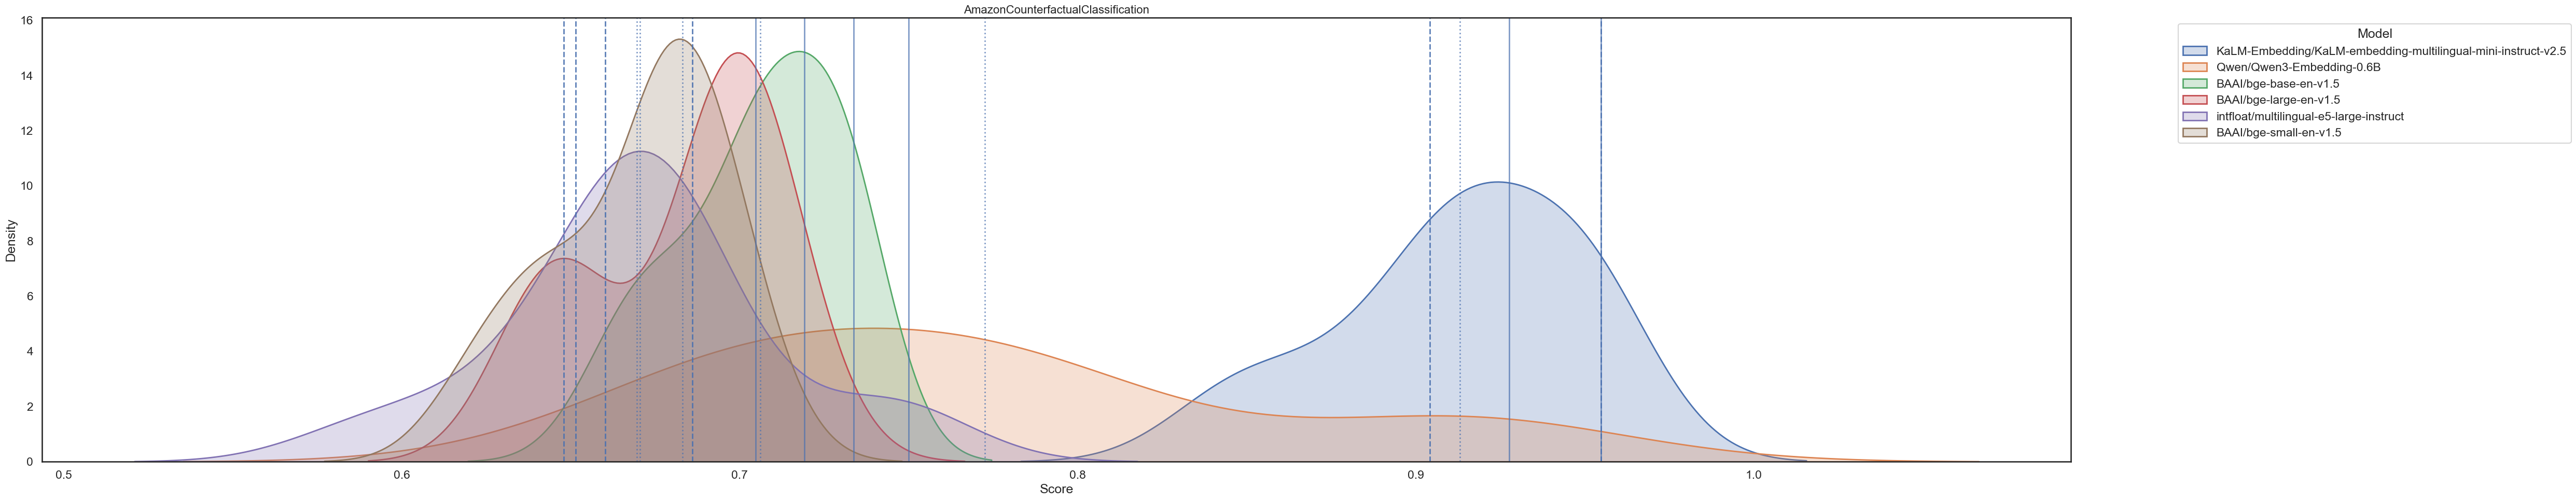

In [177]:
plot_prompt_landscape(
    df, 
    "AmazonCounterfactualClassification",
    figsize=(50, 10)
    # col_wrap: int = 3,
    # height: float = 4.0,
    # sharey: bool = False,
)

In [178]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_prompt_landscape_clean(df: pd.DataFrame, task: str):
    """
    Clean, readable distribution over prompts:
    - One row per model
    - KDE distribution
    - Baseline, mean, best marked
    - Proper axes + legend
    """

    sns.set_theme(style="white", context="talk")

    subset = df[df["task"] == task].copy()

    # Sort models
    model_order = (
        subset.groupby("model")["main_score"]
        .mean()
        .sort_values(ascending=False)
        .index
    )

    n_models = len(model_order)

    fig, axes = plt.subplots(
        n_models, 1,
        figsize=(11, 2.4 * n_models),
        sharex=True
    )

    if n_models == 1:
        axes = [axes]

    for ax, model in zip(axes, model_order):
        model_data = subset[subset["model"] == model]
        scores = model_data["main_score"]

        # --- KDE (distribution over prompts)
        sns.kdeplot(
            x=scores,
            fill=True,
            alpha=0.4,
            linewidth=2,
            ax=ax
        )

        # --- Stats
        baseline = model_data[model_data["is_baseline"] == True]["main_score"]
        mean_score = scores.mean()

        # --- Lines
        if len(baseline) > 0:
            ax.axvline(baseline.values[0], color="red", linestyle="--", linewidth=2)

        ax.axvline(mean_score, color="black", linestyle=":", linewidth=2)

        # --- Labels
        ax.set_ylabel("Density")  # Y-axis meaning
        ax.set_title(model, loc="left", fontsize=12)
        ax.set_yticks([])  # optional: remove ticks but keep label

    # --- X axis
    axes[-1].set_xlabel("Score (Performance across prompts)")

    # --- Custom legend (clean + explicit)
    legend_elements = [
        Line2D([0], [0], color="red", lw=2, linestyle="--", label="Baseline (reported score)"),
        Line2D([0], [0], color="black", lw=2, linestyle=":", label="Mean over prompts"),
    ]

    fig.legend(
        handles=legend_elements,
        loc="upper right",
        frameon=True
    )

    # --- Title
    fig.suptitle(
        f"{task}",
        fontsize=16,
        y=1.02
    )

    plt.tight_layout()
    plt.show()

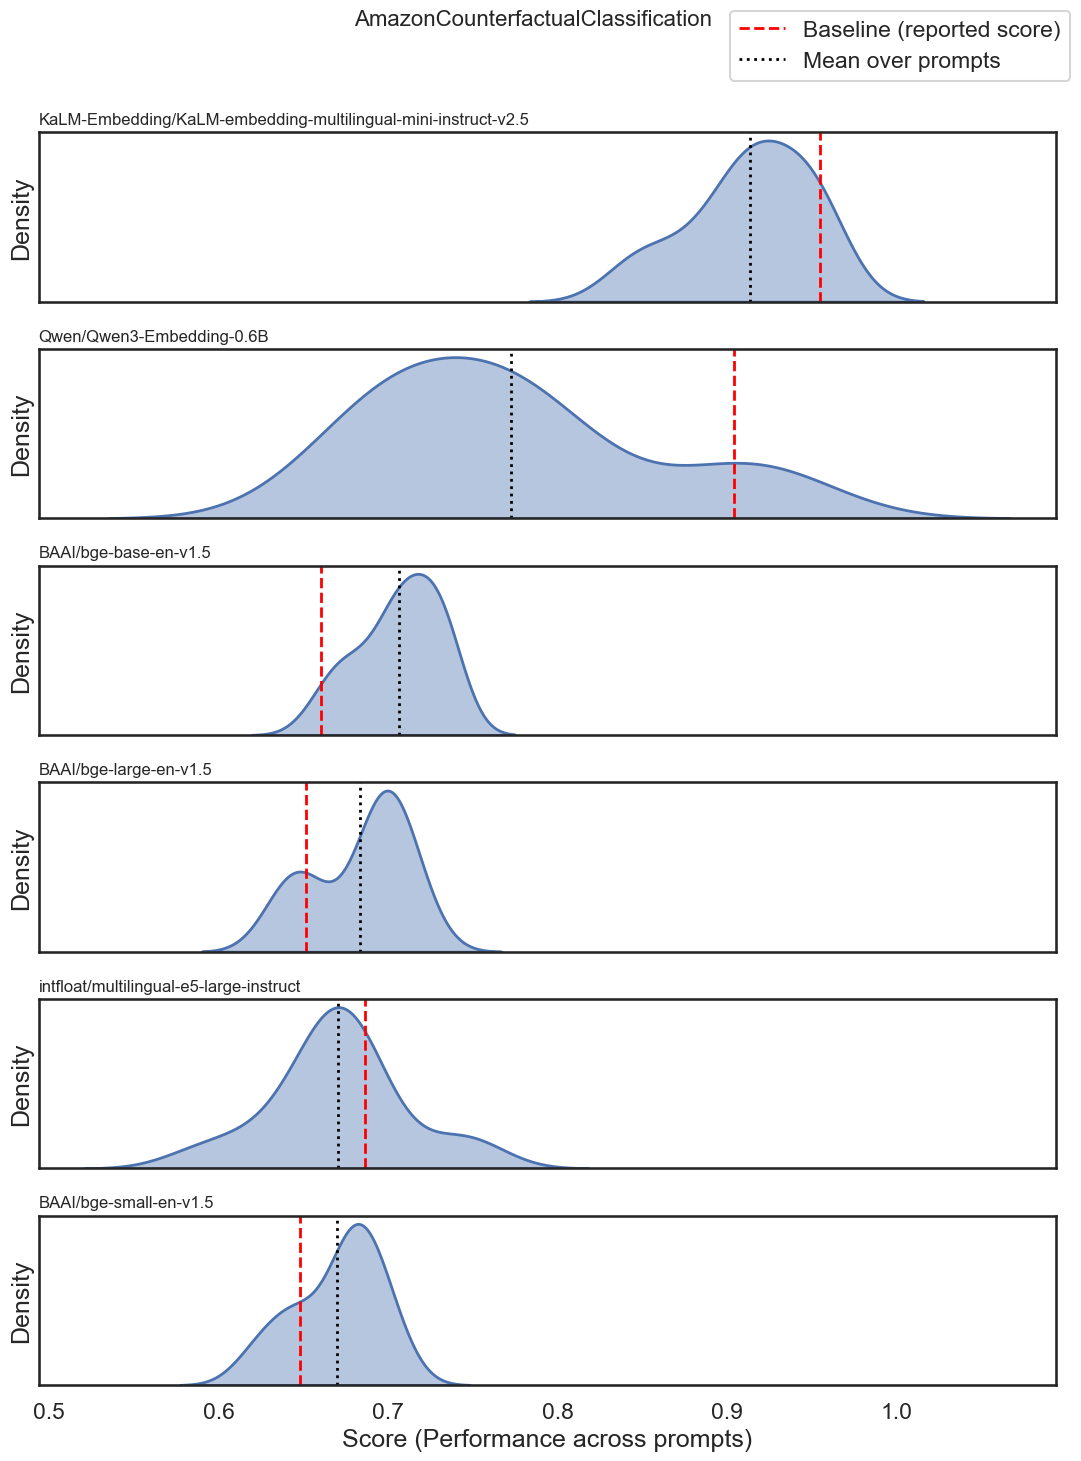

In [179]:
plot_prompt_landscape_clean(
    df, 
    "AmazonCounterfactualClassification"
    # col_wrap: int = 3,
    # height: float = 4.0,
    # sharey: bool = False,
)

In [180]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.ticker as ticker

group_tasks = {
"retrieval": [
  "MIRACLRetrievalHardNegatives.v2", # multilingual, in mmteb
  "Touche2020Retrieval.v3", # in mteb(eng, v2)
   "FEVERHardNegatives" # in mteb(eng, v2)
], 
"classification": [
  "TweetSentimentClassification", # in MTEB europe
  "ImdbClassification", # mteb eng
  "AmazonCounterfactualClassification" # mteb eng
], 
"semantic-similarity": [  
  "STS14", # in mteb eng
  "STS15", # in mteb eng
  "STS22.v2", # in mteb eng (and mmteb?)
],
"clustering": [  
  "MedrxivClusteringP2P.v2", # in mteb eng
  "StackExchangeClustering.v2", # in mteb eng
  "WikiClusteringP2P.v2", # in mmteb
]
}

def plot_category_landscape(df: pd.DataFrame, category_name: str):
    """
    Plots a grid of prompt score distributions for a specific task category.
    Rows = Models, Columns = Tasks.
    Optimized for academic papers.
    """
    # Use "paper" context for appropriately sized fonts and line widths
    sns.set_theme(style="white", context="paper") 

    tasks = group_tasks[category_name]
    
    # Filter for the tasks in this specific category
    subset = df[df["task"].isin(tasks)].copy()
    if subset.empty:
        print(f"No data found for category: {category_name}")
        return

    # Sort models by their average score across ALL tasks in this category
    model_order = (
        subset.groupby("model")["main_score"]
        .mean()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    n_models = len(model_order)
    n_tasks = len(tasks)

    # Create grid. sharex='col' is crucial: tasks have different score ranges, 
    # but we want all models to share the same x-axis scale for a single task.
    fig, axes = plt.subplots(
        nrows=n_models,
        ncols=n_tasks,
        figsize=(3.5 * n_tasks, 1.2 * n_models), # dynamically size based on grid
        sharex='col',
        sharey=False 
    )

    # Ensure 'axes' is always a 2D array even if there's only 1 row or 1 column
    if n_models == 1 and n_tasks == 1:
        axes = np.array([[axes]])
    elif n_models == 1:
        axes = np.array([axes])
    elif n_tasks == 1:
        axes = np.array([[ax] for ax in axes])

    for row_idx, model in enumerate(model_order):
        for col_idx, task in enumerate(tasks):
            ax = axes[row_idx, col_idx]
            
            # Extract data for this specific cell in the grid
            data = subset[(subset["model"] == model) & (subset["task"] == task)]
            
            if data.empty:
                ax.set_visible(False)
                continue

            scores = data["main_score"]
            
            # --- KDE (Distribution over prompts) ---
            # Fallback for single/identical values so KDE doesn't crash
            if scores.nunique() > 1:
                sns.kdeplot(
                    x=scores, fill=True, alpha=0.4, linewidth=1.5, ax=ax, color='steelblue'
                )
            else:
                ax.hist(scores, bins=10, color='steelblue', alpha=0.4)

            # --- Stats & Lines ---
            baseline = data[data["is_baseline"] == True]["main_score"]
            mean_score = scores.mean()

            if not baseline.empty:
                ax.axvline(baseline.values[0], color="red", linestyle="--", linewidth=1.5)
            ax.axvline(mean_score, color="black", linestyle=":", linewidth=1.5)

            # --- Formatting ---
            # ax.set_yticks([]) # Clean Y axis
            ax.set_ylabel("")
            ax.set_xlabel("")
            # sns.despine(ax=ax, left=True) # Remove box borders for a cleaner look
            sns.despine(ax=ax)
            ax.xaxis.set_major_locator(ticker.MaxNLocator(4))
            ax.yaxis.set_major_locator(ticker.MaxNLocator(4))
            ax.tick_params(labelbottom=True)
            
            # if row_idx == len(model_order) - 1:
            #     sns.despine(ax=ax)
            #     ax.xaxis.set_major_locator(ticker.MaxNLocator(4))
            #     ax.yaxis.set_major_locator(ticker.MaxNLocator(4))
            #     ax.tick_params(labelbottom=True)
            
                
                


            # Add column titles (Tasks) to the top row only
            if row_idx == 0:
                ax.set_title(task, fontsize=11, fontweight='bold', pad=10)
            
            # Add row titles (Models) to the first column only
            if col_idx == 0:
                # Place model name on the Y-axis label, rotated horizontally for readability
                ax.set_ylabel(model, fontsize=10, rotation=0, ha='right', va='center', labelpad=15)

    # --- X axis labels at the very bottom ---
    # for col_idx in range(n_tasks):
    #     axes[-1, col_idx].set_xlabel("Score Distribution", fontsize=10)

    # --- Title and Legend ---
    fig.suptitle(f"{category_name.capitalize()} Landscape", fontsize=14, y=1.05, fontweight='bold')
    
    legend_elements = [
        Line2D([0], [0], color="red", lw=1.5, linestyle="--", label="Reported Baseline"),
        Line2D([0], [0], color="black", lw=1.5, linestyle=":", label="Mean over Prompts")
    ]
    
    # Place legend cleanly at the top center
    fig.legend(
        handles=legend_elements, 
        loc="lower center", 
        bbox_to_anchor=(0.5, 0.98), 
        ncol=2, 
        frameon=False
    )

    plt.tight_layout()
    plt.show()

In [181]:
df['model'].unique()

array(['BAAI/bge-large-en-v1.5', 'Qwen/Qwen3-Embedding-0.6B',
       'intfloat/multilingual-e5-large-instruct', 'BAAI/bge-base-en-v1.5',
       'KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5',
       'BAAI/bge-small-en-v1.5'], dtype=object)

In [182]:
renamer = {
    "BAAI/bge-large-en-v1.5": "bge-large-en-1.5",
    "Qwen/Qwen3-Embedding-0.6B": "Qwen3-0.6B",
    "intfloat/multilingual-e5-large-instruct": "multiling-e5-large",
    "BAAI/bge-base-en-v1.5": "bge-base-en-1.5",
    "KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5": "KaLM-multiling-mini-2.5",
    "BAAI/bge-small-en-v1.5": "bge-small-en-1.5"
}

df['model'] = df['model'].apply(
    lambda x: renamer[x] if x in renamer else x
)

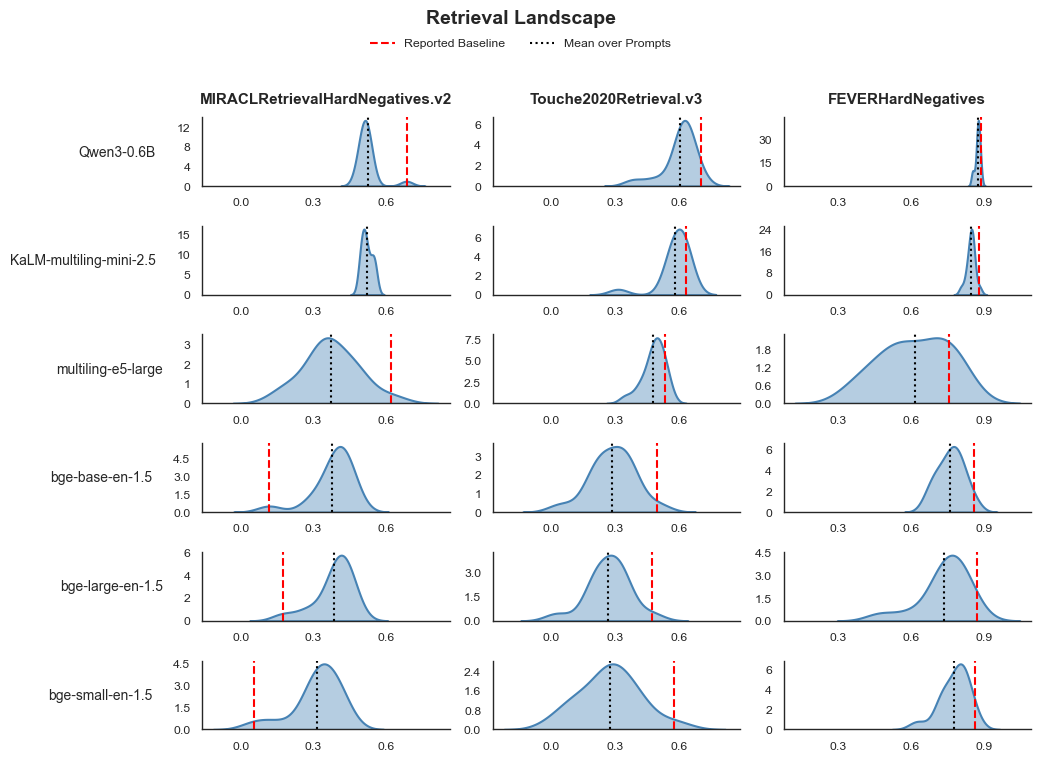

In [183]:
plot_category_landscape(df, 'retrieval')

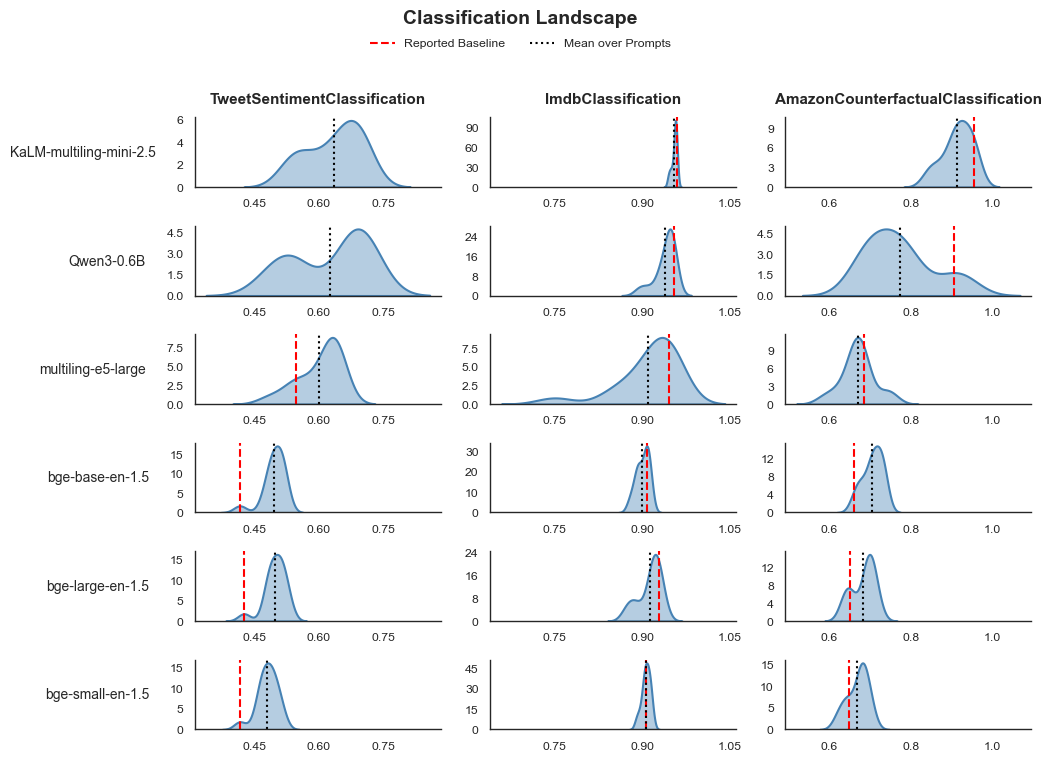

In [184]:
plot_category_landscape(df, 'classification')

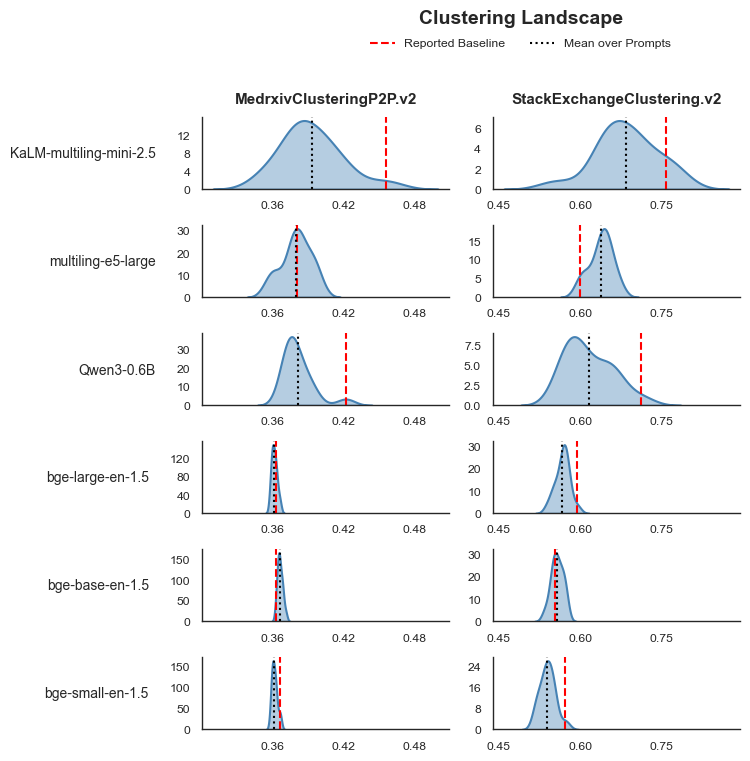

In [185]:
plot_category_landscape(df, 'clustering')

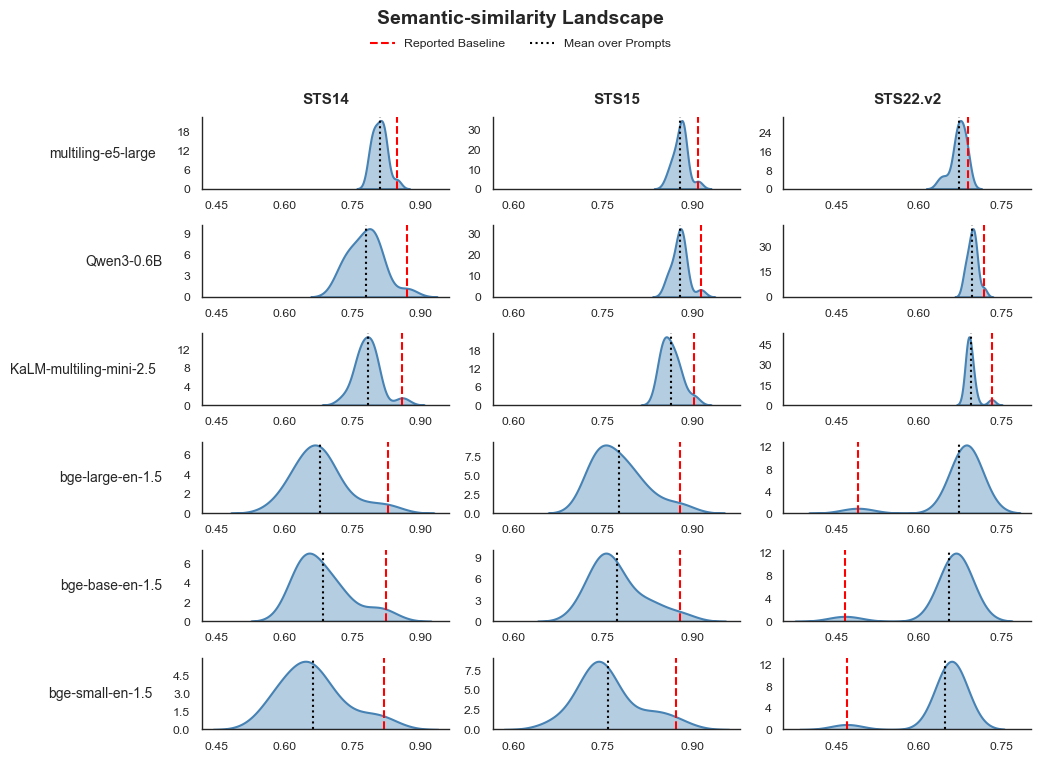

In [186]:
plot_category_landscape(df, 'semantic-similarity')